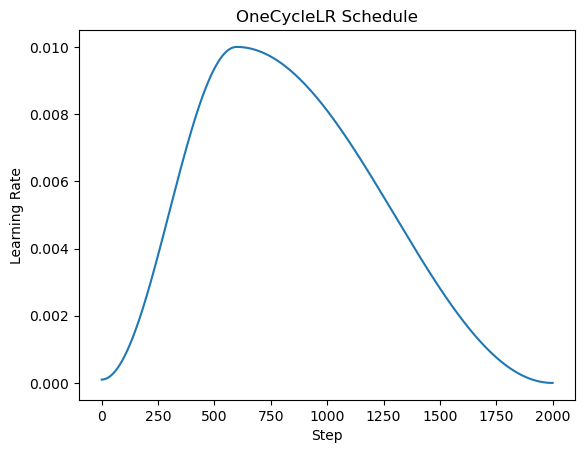

In [4]:
import torch
import matplotlib.pyplot as plt

# Dummy model and optimizer
model = torch.nn.Linear(1, 1)
batch_size = 32
dataset_size = 320  # adjust as needed
num_epochs = 200
steps_per_epoch = dataset_size // batch_size
total_steps = num_epochs * steps_per_epoch

learning_rate = 0.01
min_lr = 0.0001
pct_start = 0.3  # fraction of cycle spent increasing LR

optimizer = torch.optim.Adam(model.parameters(), lr=min_lr)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=learning_rate,
    total_steps=total_steps,
    pct_start=pct_start,
    anneal_strategy='cos',
    div_factor=learning_rate/min_lr,
    final_div_factor=learning_rate/min_lr
)

lrs = []
for step in range(total_steps):
    scheduler.step()
    lrs.append(optimizer.param_groups[0]['lr'])

plt.plot(lrs)
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('OneCycleLR Schedule')
plt.show()